**Упражнения**

### Упражнение 1

- Загрузите два временных ряда `stationarity_ts1` и `stationarity_ts2`, выполнив код ниже.

1. Постройте два временных ряда с помощью графика последовательности запусков.
4. На основе графика обсудите, является ли каждый временной ряд стационарным или нет.

### Упражнение 2
Используйте следующие инструменты, чтобы определить, являются ли временные ряды stationarity_ts1 и stationarity_ts2 стационарными или нет.

1. Сводная статистика по фрагментам.
2. Гистограммы.
3. Расширенный тест Дики-Фуллера.<br>

Обсудите результат, полученный с помощью каждого метода.

### Упражнение 3
Если один или оба набора данных из упражнений один и два нестационарны, примените преобразования, которые вы изучили в этом разделе, чтобы сделать их таковыми. Затем примените методы, которые вы изучили, чтобы обеспечить стационарность.

**Выполнените упражнений:**

**Упражнение 1:**

In [2]:
import requests
import numpy as np
from io import BytesIO

# Загрузка временных рядов
def _load_npy(url: str, timeout_s: int = 30):
    resp = requests.get(url, timeout=timeout_s)
    resp.raise_for_status()
    return np.load(BytesIO(resp.content))

base = "https://zenodo.org/records/10897398/files"
stationarity_ts1 = _load_npy(f"{base}/stationarity_ts1.npy?download=1")
stationarity_ts2 = _load_npy(f"{base}/stationarity_ts2.npy?download=1")

print("stationarity_ts1:", stationarity_ts1.shape)
print("stationarity_ts2:", stationarity_ts2.shape)


stationarity_ts1: (100,)
stationarity_ts2: (100,)


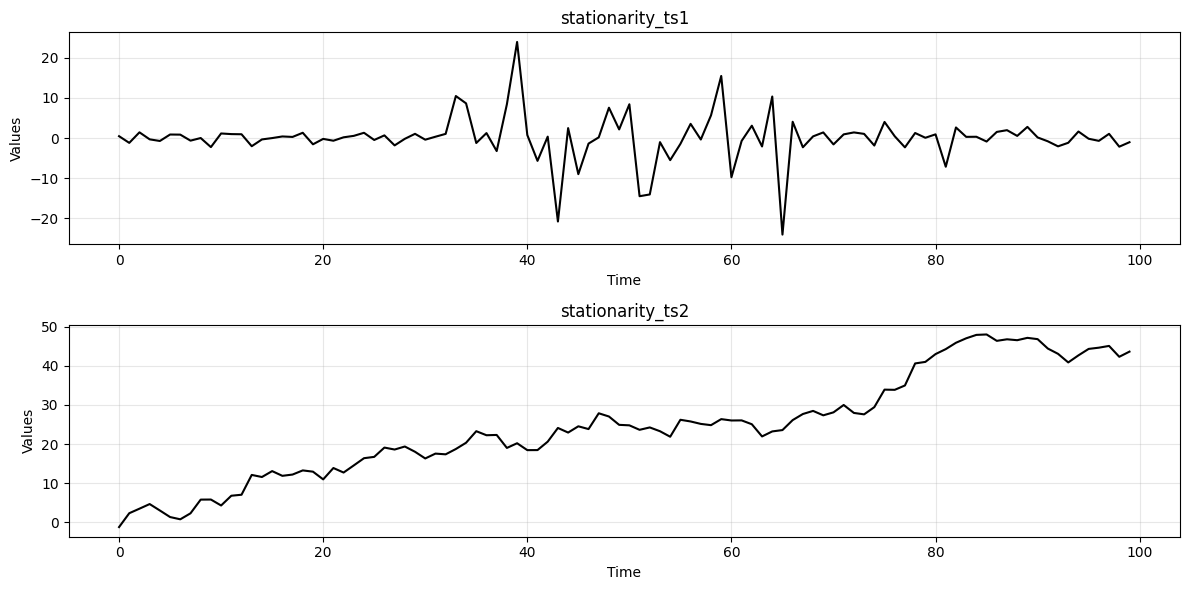

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Функция для построения графиков
def run_sequence_plot(x, y, title, xlabel="Time", ylabel="Values", ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1, figsize=(10, 3.5))
    ax.plot(x, y, 'k-')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    return ax

# run-sequence plots
t1 = np.arange(len(stationarity_ts1))
t2 = np.arange(len(stationarity_ts2))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
run_sequence_plot(t1, stationarity_ts1, title="stationarity_ts1", ax=axes[0])
run_sequence_plot(t2, stationarity_ts2, title="stationarity_ts2", ax=axes[1])
plt.tight_layout()
plt.show()


Пояснения для упражнения 1:

- Если на графике видно изменение среднего или «расширение/сжатие» разброса, то ряд **нестационарен**.
- Ниже определим это.

**Упражнение 2:**

ts1: ADF p-value = 0.0320


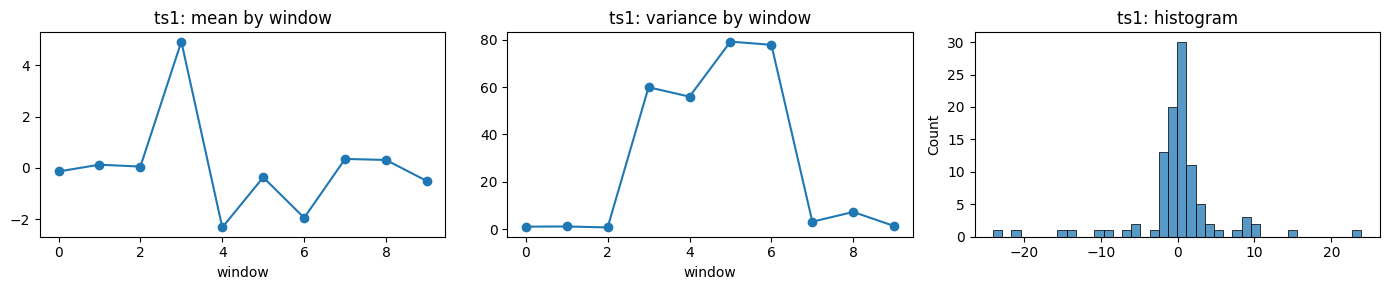

ts2: ADF p-value = 0.6189


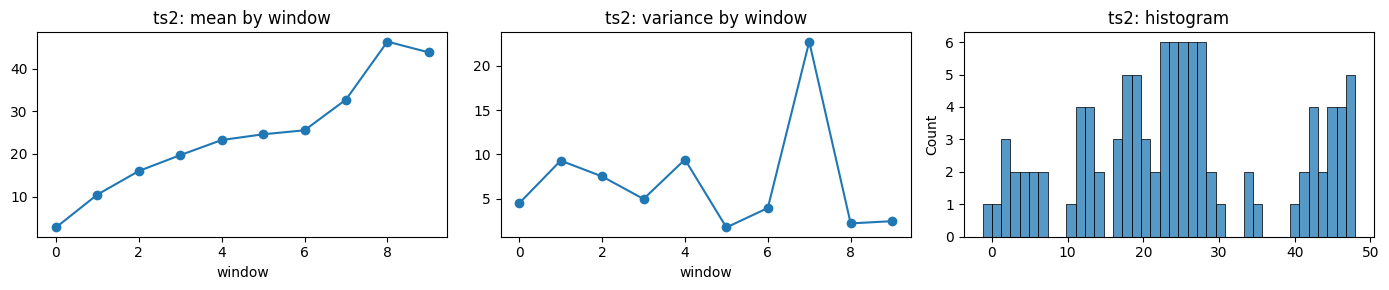

In [10]:
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

def _adf_pvalue(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    stat, pvalue, *_ = adfuller(x, autolag="AIC", result_object=False)
    return float(pvalue)

def _window_stats(x: np.ndarray, n_windows: int = 10):
    chunks = np.array_split(np.asarray(x, dtype=float), n_windows)
    means = np.array([np.nanmean(c) for c in chunks])
    vars_ = np.array([np.nanvar(c) for c in chunks])
    return means, vars_

for name, ts in [("ts1", stationarity_ts1), ("ts2", stationarity_ts2)]:
    p = _adf_pvalue(ts)
    means, vars_ = _window_stats(ts, n_windows=10)
    print(f"{name}: ADF p-value = {p:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    axes[0].plot(means, marker="o")
    axes[0].set_title(f"{name}: mean by window")
    axes[0].set_xlabel("window")

    axes[1].plot(vars_, marker="o")
    axes[1].set_title(f"{name}: variance by window")
    axes[1].set_xlabel("window")

    sns.histplot(ts, bins=40, ax=axes[2])
    axes[2].set_title(f"{name}: histogram")

    plt.tight_layout()
    plt.show()

**Упражнение 3:**

ts1: best variant = log(x+25), ADF p-value=0.0000
ts2: best variant = log+diff1, ADF p-value=0.0000


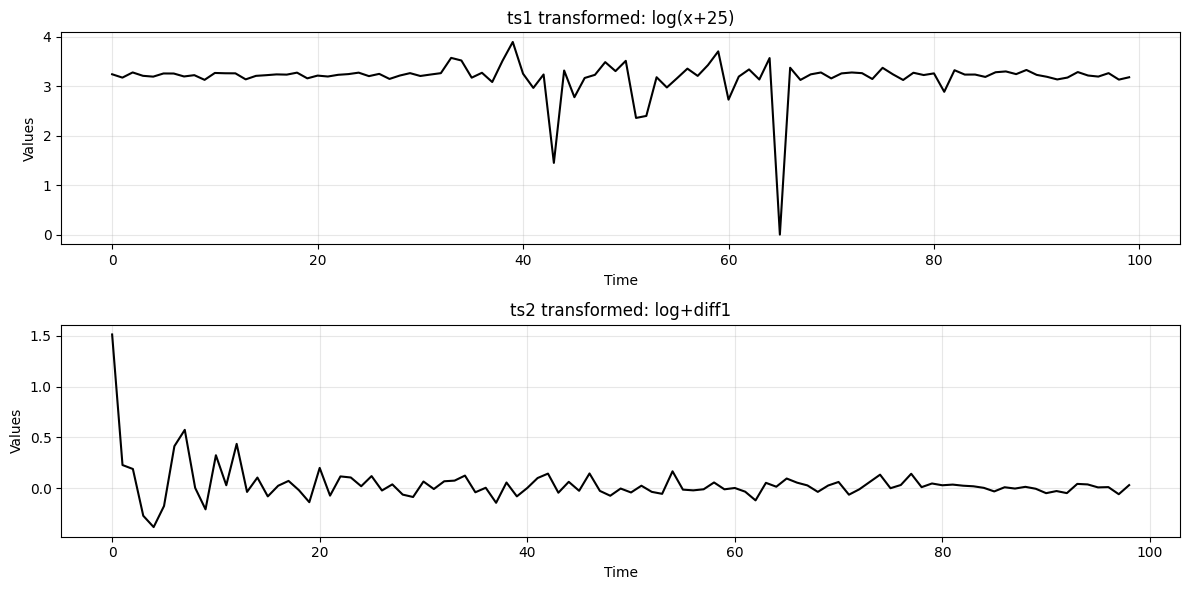

In [11]:
# Привести нестационарные ряды к стационарным
def _log_shift(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    min_val = np.nanmin(x)
    shift = (1.0 - min_val) if min_val <= 0 else 0.0
    return np.log(x + shift), shift

def _diff(x: np.ndarray, lag: int = 1):
    x = np.asarray(x, dtype=float)
    return np.diff(x, n=lag)

def _best_stationary_variant(x: np.ndarray, name: str):
    variants = []
    variants.append(("raw", x))
    x_log, shift = _log_shift(x)
    variants.append((f"log(x+{shift:.3g})", x_log))
    variants.append(("diff1", _diff(x, 1)))
    variants.append((f"log+diff1", _diff(x_log, 1)))

    scored = []
    for vname, v in variants:
        try:
            p = _adf_pvalue(v)
        except Exception:
            p = float("nan")
        scored.append((p, vname, v))

    scored_valid = [s for s in scored if np.isfinite(s[0])]
    scored_valid.sort(key=lambda t: t[0])
    best_p, best_name, best_v = scored_valid[0]
    print(f"{name}: best variant = {best_name}, ADF p-value={best_p:.4f}")
    return best_name, best_v, best_p

best1_name, best1, _ = _best_stationary_variant(stationarity_ts1, "ts1")
best2_name, best2, _ = _best_stationary_variant(stationarity_ts2, "ts2")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
run_sequence_plot(np.arange(len(best1)), best1, title=f"ts1 transformed: {best1_name}", ax=axes[0])
run_sequence_plot(np.arange(len(best2)), best2, title=f"ts2 transformed: {best2_name}", ax=axes[1])
plt.tight_layout()
plt.show()
